# Training pipeline, end-to-end — 3D Leslie, Example 1 (paper sec. 5.3.1)

This notebook runs the latent-dynamics pipeline end-to-end for the three-dimensional Leslie map (3D -> 2D latent). This is the *Example 1* regime, in which the latent Morse graph reports an **extra (spurious) attractor** that fails the semiconjugacy check — the failure mode the example is built to expose.

Every stage runs in order:

> generate data -> fit scaler -> **train** the autoencoder -> diagnose -> **Conley-Morse graph (CMGDB)** -> render -> metrics

**Runtime:** ~10-15 min (training + CMGDB at 23/23/27); lower `cfg.training.epochs` for a quicker pass. Each run writes to its own fresh
`output/notebook_demo/<example>/run_<timestamp>/` folder, so re-running (Kernel -> Restart & Run All) never
overwrites a previous run.

In [1]:
import os, json, time
from pathlib import Path
import latentdynamics
from latentdynamics.config import load_config
from latentdynamics.cli import pipeline

# Run from the repo root so the config's relative paths resolve.
os.chdir(Path(latentdynamics.__file__).resolve().parents[2])

cfg = load_config("configs/leslie3d_example1.yaml")
# Each run writes to a fresh, timestamped folder, so re-running never overwrites
# a previous run. To reproduce again, use Kernel -> Restart & Run All.
RUN_ID = time.strftime("%Y%m%d-%H%M%S")
run_root = Path(f"output/notebook_demo/leslie3d_example1/run_{RUN_ID}")
cfg.paths.output_dir = run_root
cfg.paths.data_dir = run_root / "data"
SEED = cfg.seeds[0]
SEED_DIR = cfg.paths.output_dir / f"seed_{SEED}"
print("fresh run dir:", run_root)

# For a quicker pass, uncomment:  cfg.training.epochs = 300
print(f"system = {cfg.system.name}   dims {cfg.arch.high_dims} -> {cfg.arch.low_dims}   seed = {SEED}")
print(f"CMGDB subdiv = {cfg.cmgdb.subdiv_init}/{cfg.cmgdb.subdiv_min}/{cfg.cmgdb.subdiv_max}, padding={cfg.cmgdb.padding}")

fresh run dir: output/notebook_demo/leslie3d_example1/run_20260527-170402
system = leslie3d   dims 3 -> 2   seed = 2
CMGDB subdiv = 23/23/27, padding=True


## The pipeline

`pipeline.run(cfg, stages=[...])` runs one or more stages and persists their artifacts to disk.
We call it stage-by-stage so we can inspect each step.

## 1-2. Generate trajectory data + fit the MinMax scaler

In [2]:
pipeline.run(cfg, stages=["data", "scale"], verbose=True)
for f in ("train.csv", "val.csv"):
    p = cfg.paths.data_dir / f
    print(f"{f}: {'ok' if p.exists() else 'MISSING'}  ({p.stat().st_size if p.exists() else 0} bytes)")

system: leslie3d (dim=3)
  lower_bounds: [0.0, 0.0, 0.0]
  upper_bounds: [220.0, 154.0, 108.0]
wrote output/notebook_demo/leslie3d_example1/run_20260527-170402/data/train.csv (120000 pairs)
wrote output/notebook_demo/leslie3d_example1/run_20260527-170402/data/val.csv (150000 pairs)
fitted minmax scaler on 240000 samples (3 dims)
wrote output/notebook_demo/leslie3d_example1/run_20260527-170402/scalers/train/scaler.gz
train.csv: ok  (8228586 bytes)
val.csv: ok  (10285060 bytes)


## 3. Train the autoencoder (encoder + latent map + decoder)

In [3]:
pipeline.run(cfg, stages=["train"], verbose=True)
ts = json.load(open(SEED_DIR / "training_summary.json"))
print("epochs run:", ts.get("n_epochs_run"), " | train minutes:", round(ts.get("train_duration_minutes", 0), 2))
print("final val losses:", {k: round(v["final"], 6) for k, v in ts["val"].items()})

device: mps
loss_weights=[10.0, 10.0, 1.0]


 38%|███▊      | 378/1000 [09:21<15:23,  1.49s/it, train=6.2045e-03, val=6.6047e-03]

early stopping at epoch 379
trained 379 epochs in 9.36 min
checkpoint and logs written to output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2
epochs run: 379  | train minutes: 9.36
final val losses: {'loss_ae1': 0.000451, 'loss_ae2': 0.000189, 'loss_dyn': 0.000209, 'loss_cycle_pred': 0.000125, 'loss_total': 0.006605}


## 4. Diagnose the trained latent map (health checks)

In [4]:
pipeline.run(cfg, stages=["diagnose"], verbose=True)
diag = json.load(open(SEED_DIR / "diagnose.json"))
print("diagnostic:", diag.get("diagnostic"))
print("hard_flags:", diag.get("hard_flags"))

diagnose: ok
  -> output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/diagnose.json
  -> output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/figures/latent_pointcloud.png
  -> output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/figures/latent_map_one_step.png
diagnostic: ok
hard_flags: {'encoder_collapsed': False, 'latent_map_overcontracted': False}


## 5. Conley-Morse graph (CMGDB)

The expensive stage: build the box map of the trained latent dynamics, compute the Morse
decomposition and the Conley index of each Morse set. Writes `MG/morse_graph` (DOT) and
`MG/morse_sets` (CSV).

In [5]:
pipeline.run(cfg, stages=["morse"], verbose=True)

latent bounds (encoded_data): lower=[-0.5984475612640381, -0.570245623588562] upper=[0.48353126645088196, 0.7279654145240784]
CMGDB: subdiv_init=23 min=23 max=27 padding=True backend=auto
morse graph DOT  -> output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/MG/morse_graph
morse sets CSV   -> output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/MG/morse_sets
computation took 6.66 min


[{'cell_index': 0,
  'train_file': 'train',
  'seed': 2,
  'device': 'mps',
  'output_dir': 'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2',
  'manifest': 'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/run_manifest.json'}]

## 6-7. Render figures + compute metrics

In [6]:
pipeline.run(cfg, stages=["render", "metrics"], verbose=True)

render: using the approximate uniform-grid RoA -- no exact RoA artifact found; re-run the morse stage to compute the RoA on CMGDB's own grid
render: 7 file(s) under output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2
metrics -> output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/metrics.json: {'minimal_morse_labels': [0, 1], 'minimal_morse_sets': {'0': {'n_boxes': 7489, 'tau_bar': 0.0002652924376889132, 'n_semiconjugacy_samples': 1891, 'max_semiconjugacy_error': 0.009571014903485775, 'is_spurious_attractor': True}, '1': {'n_boxes': 3921, 'tau_bar': 0.000289529380097543, 'n_semiconjugacy_samples': 131, 'max_semiconjugacy_error': 0.034295640885829926, 'is_spurious_attractor': True}}, 'morse_graph_consistency': {'n_morse_sets': 3, 'n_minimal_attractors': 2, 'attractor_type_nonminimal': [], 'n_trivial_index': 0, 'consistent': True}}


[{'cell_index': 0,
  'train_file': 'train',
  'seed': 2,
  'device': 'mps',
  'output_dir': 'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2',
  'render': {'figures': ['output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/MG/morse_graph.pdf',
    'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/MG/morse_graph.png',
    'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/MG/morse_sets.pdf',
    'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/MG/morse_sets.png',
    'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/MG/regions_of_attraction.png',
    'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/MG/morse_sets_with_overlay.pdf',
    'output/notebook_demo/leslie3d_example1/run_20260527-170402/seed_2/figures/latent_trajectory.png']},
  'metrics': {'minimal_morse_labels': [0, 1],
   'minimal_morse_sets': {'0': {'n_boxes': 7489,
     'tau_bar': 0.0002652924376889132,
     'n

## Results

The latent Morse graph (Hasse diagram), the Morse sets, and the metrics — including
`morse_graph_consistency`, which flags any attractor-type Conley index that is not a minimal
node (a sign the subdivision is too coarse).

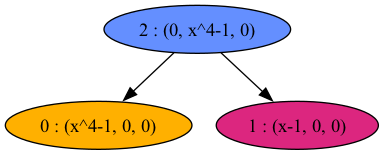

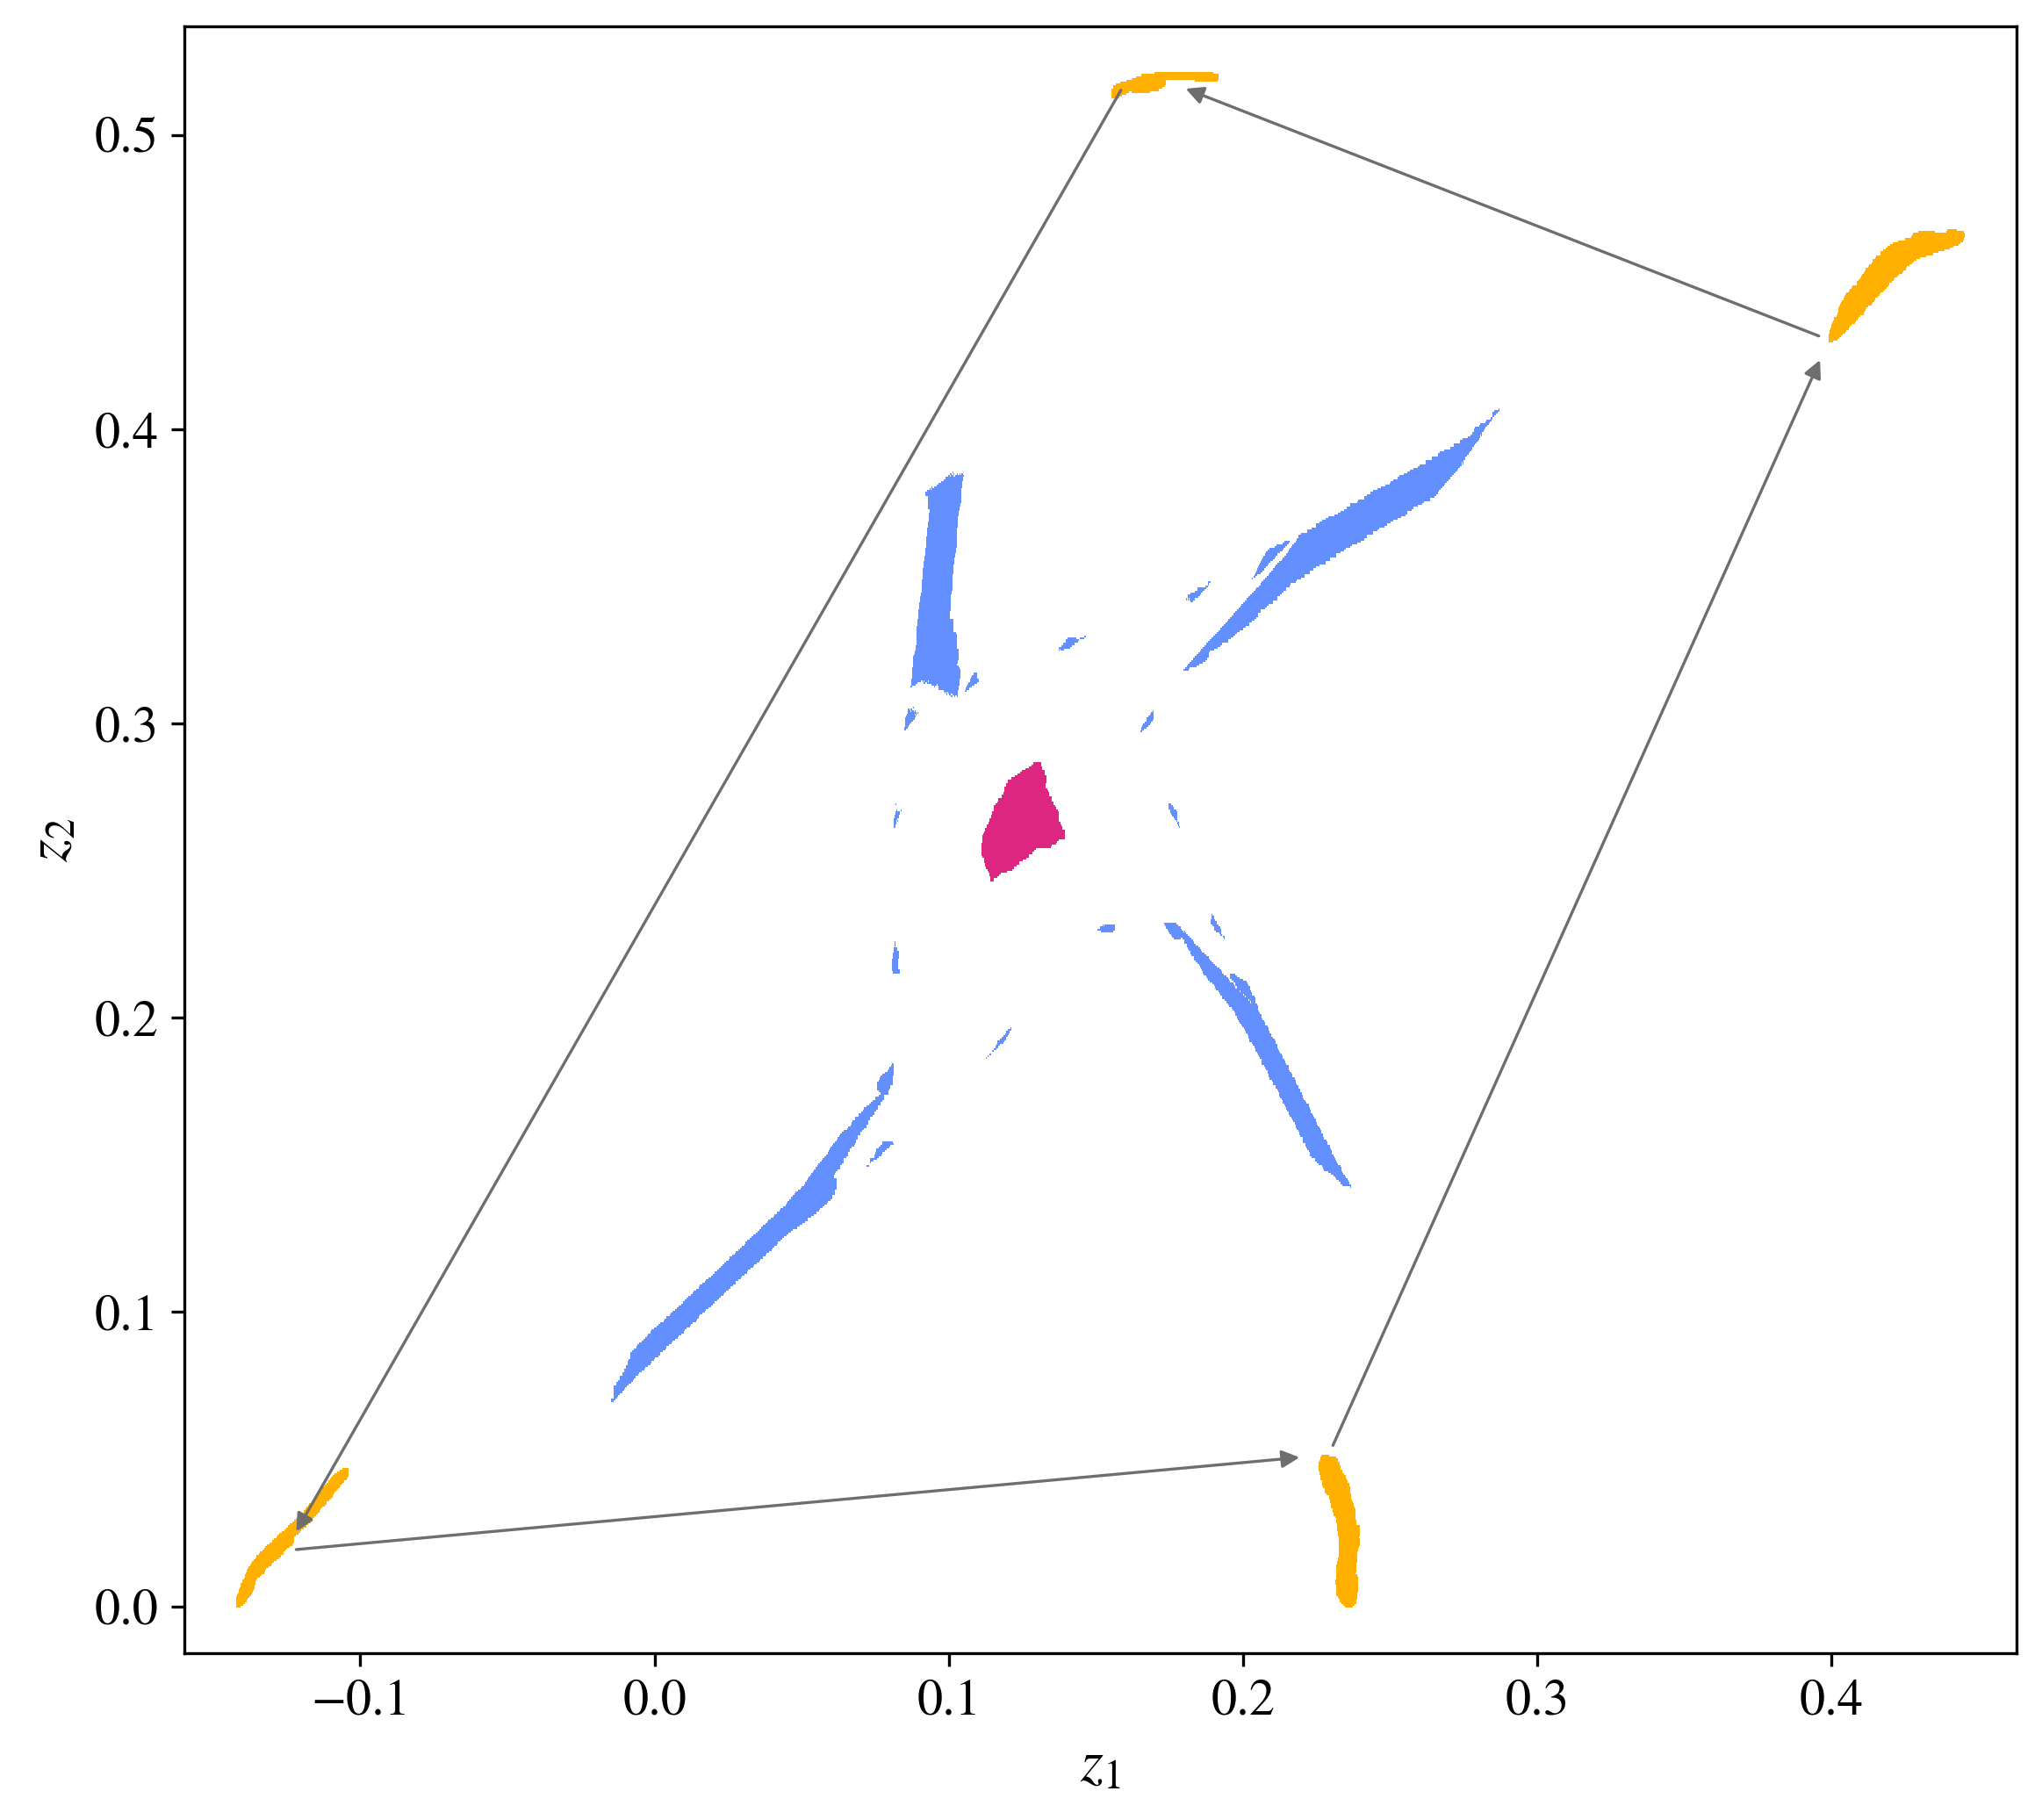

minimal_morse_labels: [0, 1]
consistency: {'n_morse_sets': 3, 'n_minimal_attractors': 2, 'attractor_type_nonminimal': [], 'n_trivial_index': 0, 'consistent': True}


In [7]:
from IPython.display import Image, display
mg = SEED_DIR / "MG"
display(Image(filename=str(mg / "morse_graph.png")))
sets = mg / "morse_sets_with_overlay.png"
if not sets.exists():
    sets = mg / "morse_sets.png"
display(Image(filename=str(sets)))
m = json.load(open(SEED_DIR / "metrics.json"))
print("minimal_morse_labels:", m.get("minimal_morse_labels"))
print("consistency:", m.get("morse_graph_consistency"))